In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("dataset_balanced_final.csv")

print(df.shape)

df.head()

(10610, 8)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,Label
0,2.877713,293.983431,4.517476,13,0,12,53248,ATTACK
1,3.455120,362.939603,5.499085,19,0,19,53248,ATTACK
2,0.051562,33668.159007,96.970504,5,1,5,65535,ATTACK
3,2.422511,356.654748,3.302359,8,0,8,547,ATTACK
4,0.197157,32821.534390,45.648866,9,1,9,65535,NORMAL


In [3]:
df["Label"] = df["Label"].map({
    "NORMAL":0,
    "ATTACK":1
})

print(df["Label"].value_counts())

Label
1    5305
0    5305
Name: count, dtype: int64


In [4]:
X = df.drop("Label", axis=1)

y = df["Label"]

features = X.columns

print(features)

Index(['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Total Fwd Packets',
       'SYN Flag Count', 'ACK Flag Count', 'Init_Win_bytes_forward'],
      dtype='object')


In [5]:
normal = df[df["Label"]==0]

attack = df[df["Label"]==1]

print("="*60)
print("NORMAL")
print("="*60)

display(normal.describe().T)

print("="*60)
print("ATTACK")
print("="*60)

display(attack.describe().T)

NORMAL


,count,mean,std,min,25%,50%,75%,max
Flow Duration,5305.0,1.917572,1.994254,0.005885,0.162141,0.658928,4.357952,4.998009e+00
Flow Bytes/s,5305.0,36742.672367,105666.859444,36.065168,5921.569955,15307.511025,35567.065033,5.178161e+06
Flow Packets/s,5305.0,41.242549,58.234598,0.614685,6.859221,20.712929,59.067877,5.097805e+02
Total Fwd Packets,5305.0,29.783600,62.499227,3.000000,6.000000,11.000000,24.000000,6.960000e+02
SYN Flag Count,5305.0,0.540057,1.528249,0.000000,0.000000,0.000000,1.000000,2.700000e+01
ACK Flag Count,5305.0,29.518379,62.253872,2.000000,6.000000,11.000000,24.000000,6.960000e+02
Init_Win_bytes_forward,5305.0,21104.555137,30032.348541,0.000000,16.000000,501.000000,65535.000000,6.553500e+04
Label,5305.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


ATTACK


,count,mean,std,min,25%,50%,75%,max
Flow Duration,5305.0,3.365872,1.294204,0.006254,2.878655,3.501332,4.432602,4.997871
Flow Bytes/s,5305.0,7747.522117,39976.479014,41.344383,157.170933,254.717555,387.391811,640924.489846
Flow Packets/s,5305.0,12.573734,33.816868,0.648938,2.296210,3.805908,5.690606,479.677951
Total Fwd Packets,5305.0,35.173233,96.727968,3.000000,4.000000,12.000000,19.000000,783.000000
SYN Flag Count,5305.0,18.606032,92.361211,0.000000,0.000000,0.000000,2.000000,783.000000
ACK Flag Count,5305.0,17.111216,34.170455,0.000000,4.000000,11.000000,18.000000,614.000000
Init_Win_bytes_forward,5305.0,46605.235061,22574.487619,0.000000,53248.000000,53248.000000,64240.000000,65535.000000
Label,5305.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
summary = pd.DataFrame()

summary["NORMAL Median"] = normal.median(numeric_only=True)

summary["ATTACK Median"] = attack.median(numeric_only=True)

summary["Difference"] = (
    summary["ATTACK Median"] -
    summary["NORMAL Median"]
)

summary

,NORMAL Median,ATTACK Median,Difference
Flow Duration,0.658928,3.501332,2.842404
Flow Bytes/s,15307.511025,254.717555,-15052.793470
Flow Packets/s,20.712929,3.805908,-16.907020
Total Fwd Packets,11.000000,12.000000,1.000000
SYN Flag Count,0.000000,0.000000,0.000000
ACK Flag Count,11.000000,11.000000,0.000000
Init_Win_bytes_forward,501.000000,53248.000000,52747.000000
Label,0.000000,1.000000,1.000000


C:\Users\evand\AppData\Local\Temp\ipykernel_22224\3959411132.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\3959411132.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\3959411132.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\3959411132.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\3959411132.py:14: UserWarning: set_ticklabels() should

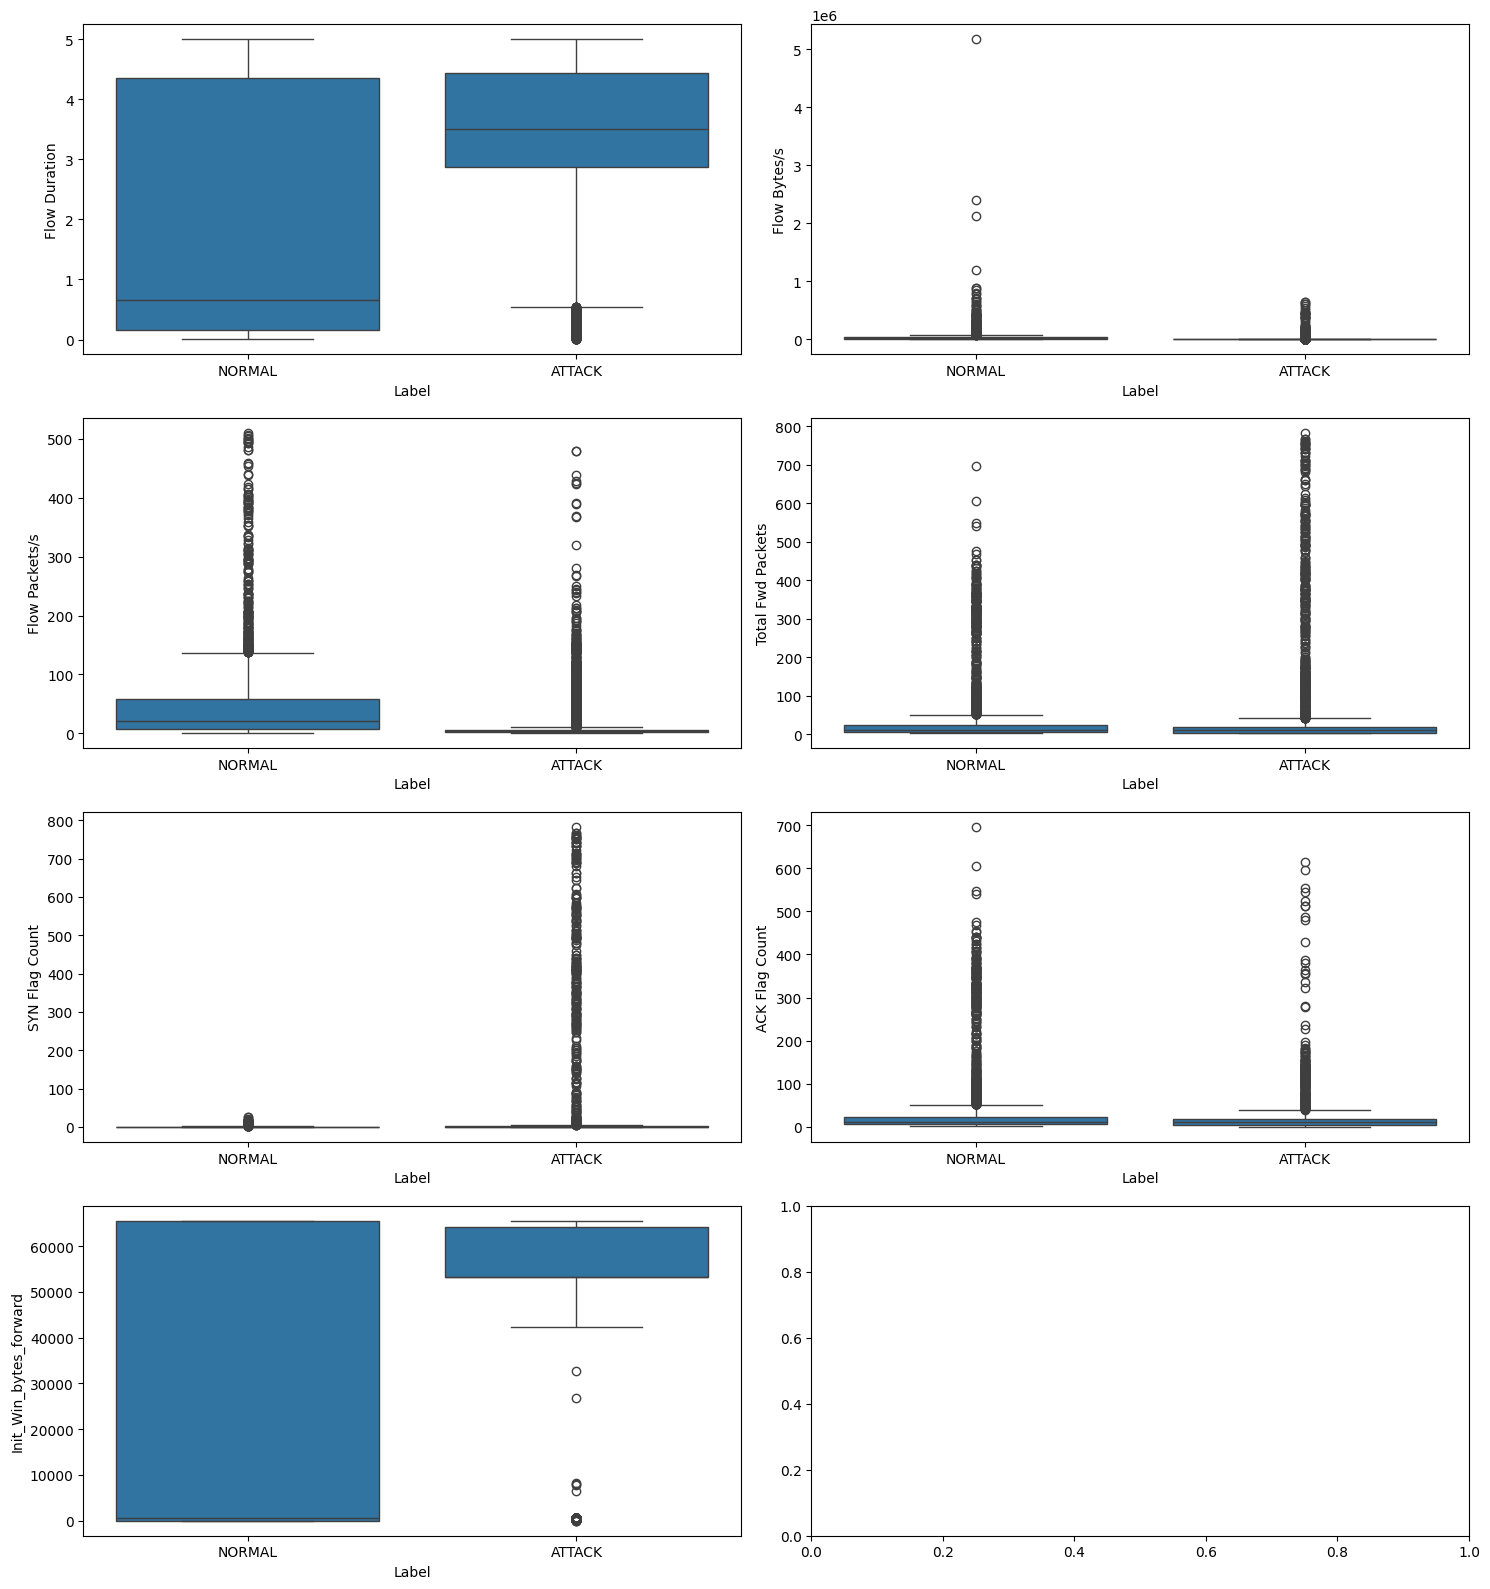

In [7]:
fig, axes = plt.subplots(4,2, figsize=(15,16))

axes = axes.flatten()

for i, col in enumerate(features):

    sns.boxplot(
        data=df,
        x="Label",
        y=col,
        ax=axes[i]
    )

    axes[i].set_xticklabels([
        "NORMAL",
        "ATTACK"
    ])

plt.tight_layout()

plt.show()

C:\Users\evand\AppData\Local\Temp\ipykernel_22224\308929851.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\308929851.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\308929851.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\308929851.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([
C:\Users\evand\AppData\Local\Temp\ipykernel_22224\308929851.py:14: UserWarning: set_ticklabels() should only

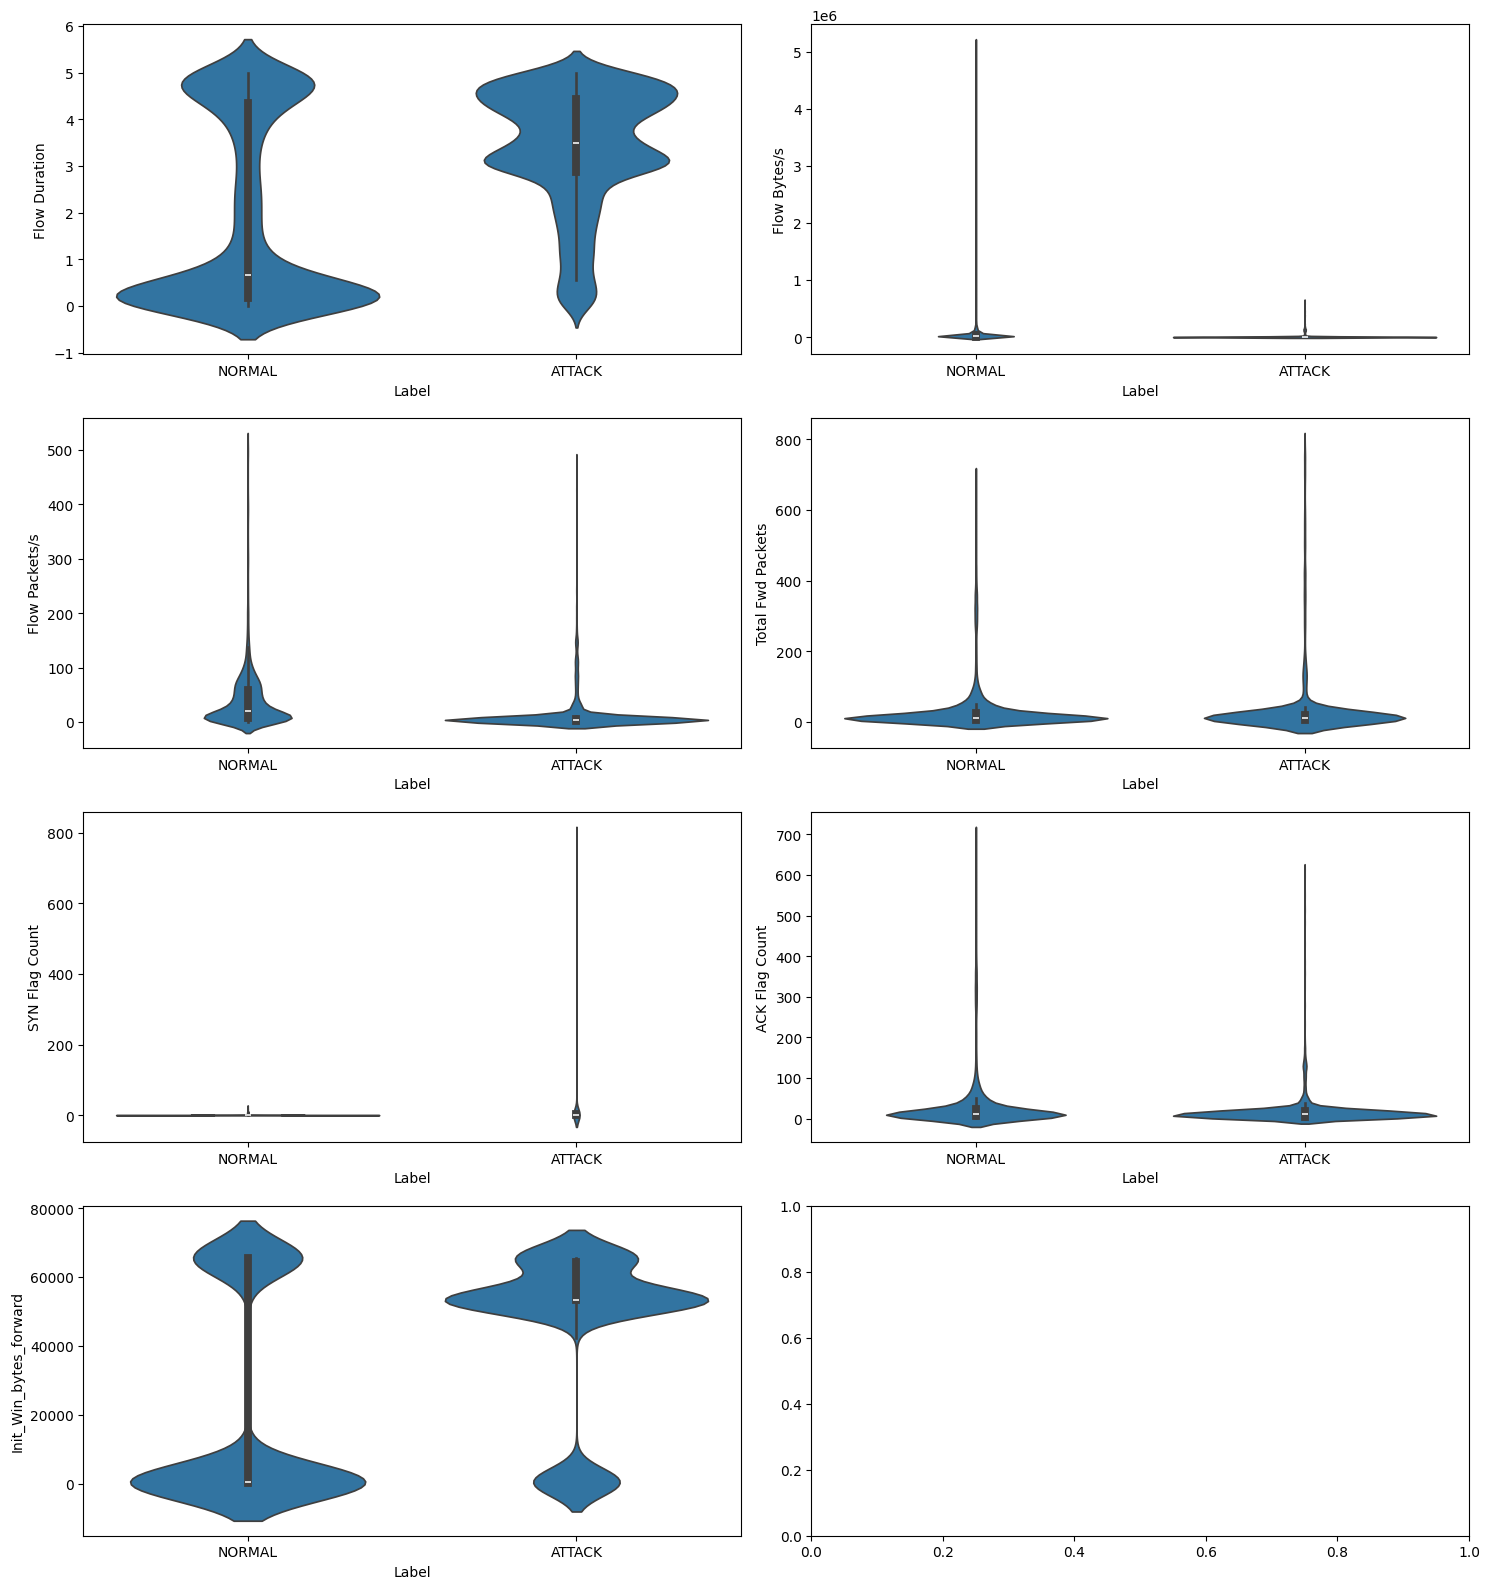

In [8]:
fig, axes = plt.subplots(4,2, figsize=(15,16))

axes = axes.flatten()

for i,col in enumerate(features):

    sns.violinplot(
        data=df,
        x="Label",
        y=col,
        ax=axes[i]
    )

    axes[i].set_xticklabels([
        "NORMAL",
        "ATTACK"
    ])

plt.tight_layout()

plt.show()

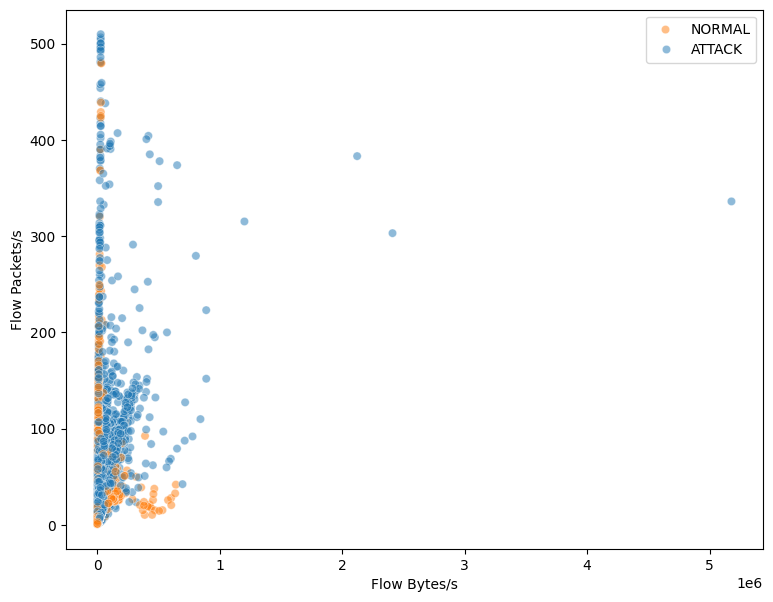

In [9]:
plt.figure(figsize=(9,7))

sns.scatterplot(

    data=df,

    x="Flow Bytes/s",

    y="Flow Packets/s",

    hue="Label",

    alpha=0.5

)

plt.legend(["NORMAL","ATTACK"])

plt.show()

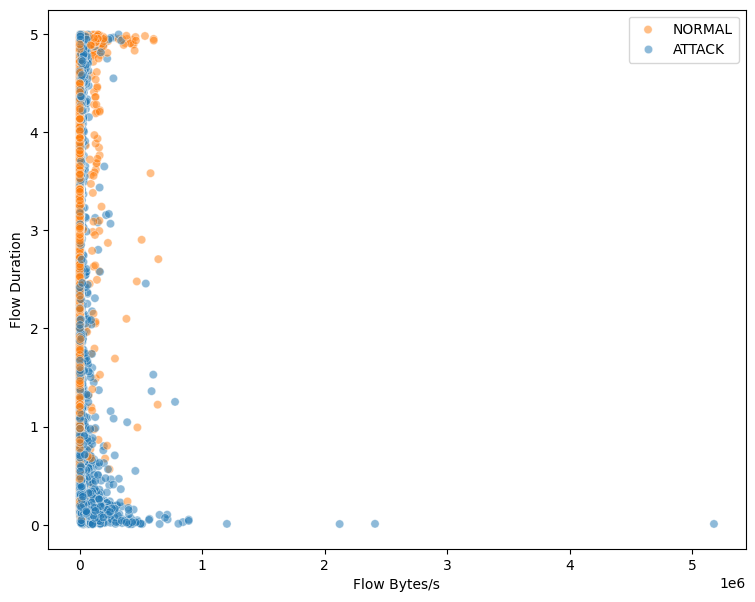

In [10]:
plt.figure(figsize=(9,7))

sns.scatterplot(

    data=df,

    x="Flow Bytes/s",

    y="Flow Duration",

    hue="Label",

    alpha=0.5

)

plt.legend(["NORMAL","ATTACK"])

plt.show()

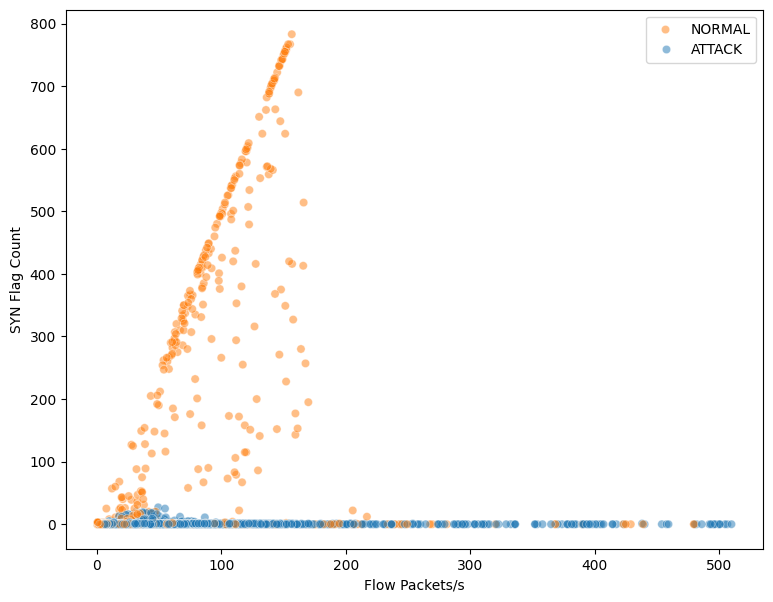

In [11]:
plt.figure(figsize=(9,7))

sns.scatterplot(

    data=df,

    x="Flow Packets/s",

    y="SYN Flag Count",

    hue="Label",

    alpha=0.5

)

plt.legend(["NORMAL","ATTACK"])

plt.show()

In [12]:
pca_df = pd.DataFrame({

    "PC1":X_pca[:,0],

    "PC2":X_pca[:,1],

    "Label":df["Label"]

})

pca_df.head()

NameError: name 'X_pca' is not defined

In [13]:
plt.figure(figsize=(9,7))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Label",

    alpha=0.6

)

plt.legend([
    "NORMAL",
    "ATTACK"
])

plt.title("PCA Visualization")

plt.show()

NameError: name 'pca_df' is not defined

<Figure size 900x700 with 0 Axes>

In [14]:
print("="*60)

print("NORMAL")

print("="*60)

display(normal.drop("Label",axis=1).corr())

print("="*60)

print("ATTACK")

print("="*60)

display(attack.drop("Label",axis=1).corr())

NORMAL


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward
Flow Duration,1.000000,-0.153917,-0.424605,0.447157,-0.075344,0.447244,-0.500710
Flow Bytes/s,-0.153917,1.000000,0.321415,-0.007867,-0.011579,-0.006926,0.068131
Flow Packets/s,-0.424605,0.321415,1.000000,0.024764,0.031808,0.025251,0.150154
Total Fwd Packets,0.447157,-0.007867,0.024764,1.000000,0.117321,0.999715,-0.165012
SYN Flag Count,-0.075344,-0.011579,0.031808,0.117321,1.000000,0.094578,0.363151
ACK Flag Count,0.447244,-0.006926,0.025251,0.999715,0.094578,1.000000,-0.168294
Init_Win_bytes_forward,-0.500710,0.068131,0.150154,-0.165012,0.363151,-0.168294,1.000000


ATTACK


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward
Flow Duration,1.000000,0.079629,-0.163362,0.255904,0.174685,0.249044,-0.107996
Flow Bytes/s,0.079629,1.000000,0.169521,0.210891,0.085800,0.361833,-0.277703
Flow Packets/s,-0.163362,0.169521,1.000000,0.597870,0.568321,0.148548,-0.330521
Total Fwd Packets,0.255904,0.210891,0.597870,1.000000,0.934830,0.298749,-0.445941
SYN Flag Count,0.174685,0.085800,0.568321,0.934830,1.000000,-0.059355,-0.389639
ACK Flag Count,0.249044,0.361833,0.148548,0.298749,-0.059355,1.000000,-0.194483
Init_Win_bytes_forward,-0.107996,-0.277703,-0.330521,-0.445941,-0.389639,-0.194483,1.000000


In [15]:
print("="*60)
print("DATASET CHARACTERISTIC")
print("="*60)

print()

print("Jumlah NORMAL :",len(normal))
print("Jumlah ATTACK :",len(attack))

print()

print("Jumlah Feature :",len(features))

print()

print("Dataset telah seimbang (Balanced Dataset).")

print("Tidak terdapat missing value.")

print("Tidak terdapat duplicate data.")

print("Visualisasi menunjukkan sebagian besar fitur memiliki area overlap antara kelas NORMAL dan ATTACK.")

print("Hal ini menunjukkan bahwa pemisahan kelas tidak dapat dilakukan hanya menggunakan threshold sederhana (if-else), sehingga diperlukan algoritma Machine Learning untuk mempelajari hubungan antar fitur.")

DATASET CHARACTERISTIC

Jumlah NORMAL : 5305
Jumlah ATTACK : 5305

Jumlah Feature : 7

Dataset telah seimbang (Balanced Dataset).
Tidak terdapat missing value.
Tidak terdapat duplicate data.
Visualisasi menunjukkan sebagian besar fitur memiliki area overlap antara kelas NORMAL dan ATTACK.
Hal ini menunjukkan bahwa pemisahan kelas tidak dapat dilakukan hanya menggunakan threshold sederhana (if-else), sehingga diperlukan algoritma Machine Learning untuk mempelajari hubungan antar fitur.


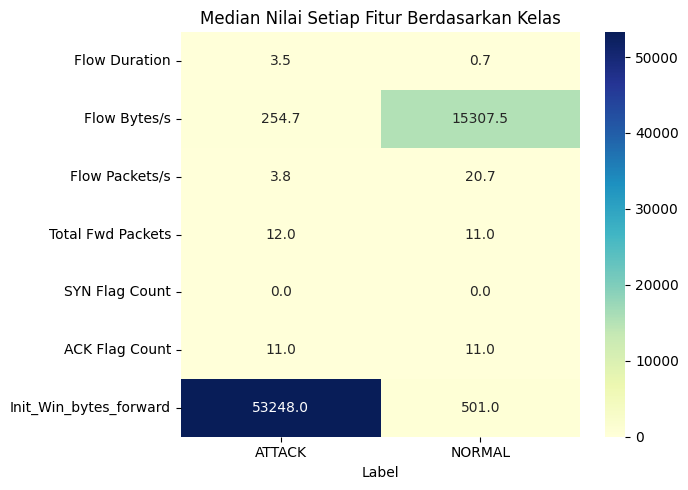

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_balanced_final.csv")

summary = (
    df.groupby("Label")
      .median(numeric_only=True)
      .T
)

plt.figure(figsize=(7,5))

sns.heatmap(
    summary,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Median Nilai Setiap Fitur Berdasarkan Kelas")

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

df = pd.read_csv("dataset_balanced_final.csv")

In [18]:
normal = df[df["Label"]=="NORMAL"]
attack = df[df["Label"]=="ATTACK"]

In [19]:
hasil = []

fitur = df.columns.drop("Label")

for f in fitur:

    normal_min = normal[f].min()
    normal_max = normal[f].max()

    attack_min = attack[f].min()
    attack_max = attack[f].max()

    overlap = not (
        normal_max < attack_min or
        attack_max < normal_min
    )

    hasil.append([
        f,
        normal_min,
        normal_max,
        attack_min,
        attack_max,
        "Ya" if overlap else "Tidak"
    ])

overlap_df = pd.DataFrame(
    hasil,
    columns=[
        "Feature",
        "Normal Min",
        "Normal Max",
        "Attack Min",
        "Attack Max",
        "Overlap"
    ]
)

overlap_df

,Feature,Normal Min,Normal Max,Attack Min,Attack Max,Overlap
0,Flow Duration,0.005885,4.998009e+00,0.006254,4.997871,Ya
1,Flow Bytes/s,36.065168,5.178161e+06,41.344383,640924.489846,Ya
2,Flow Packets/s,0.614685,5.097805e+02,0.648938,479.677951,Ya
3,Total Fwd Packets,3.000000,6.960000e+02,3.000000,783.000000,Ya
4,SYN Flag Count,0.000000,2.700000e+01,0.000000,783.000000,Ya
5,ACK Flag Count,2.000000,6.960000e+02,0.000000,614.000000,Ya
6,Init_Win_bytes_forward,0.000000,6.553500e+04,0.000000,65535.000000,Ya


In [20]:
overlap_df = overlap_df.round(2)

overlap_df

,Feature,Normal Min,Normal Max,Attack Min,Attack Max,Overlap
0,Flow Duration,0.01,5.00,0.01,5.00,Ya
1,Flow Bytes/s,36.07,5178161.38,41.34,640924.49,Ya
2,Flow Packets/s,0.61,509.78,0.65,479.68,Ya
3,Total Fwd Packets,3.00,696.00,3.00,783.00,Ya
4,SYN Flag Count,0.00,27.00,0.00,783.00,Ya
5,ACK Flag Count,2.00,696.00,0.00,614.00,Ya
6,Init_Win_bytes_forward,0.00,65535.00,0.00,65535.00,Ya


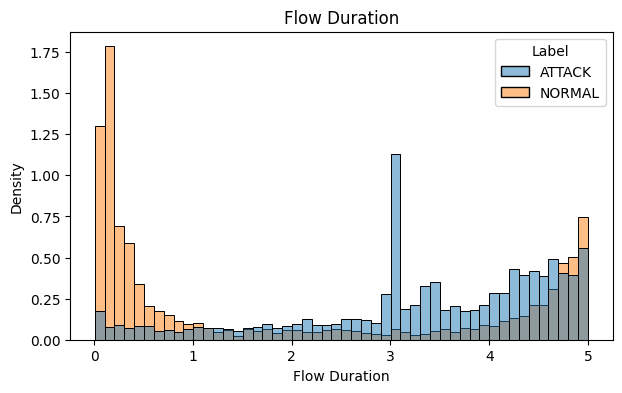

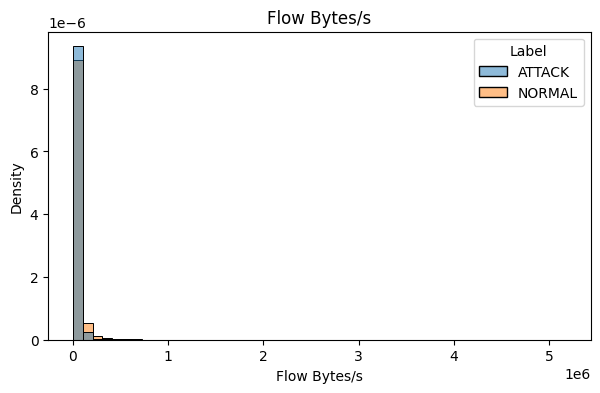

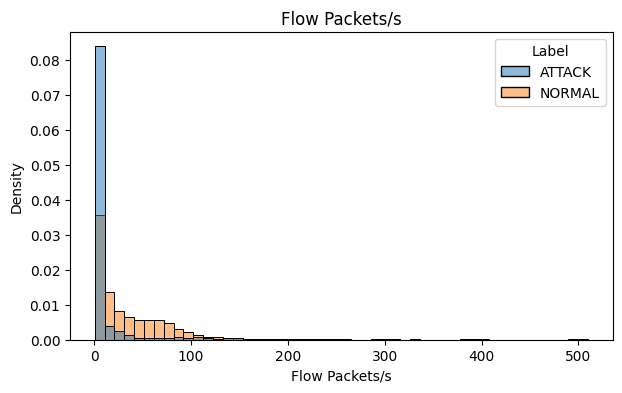

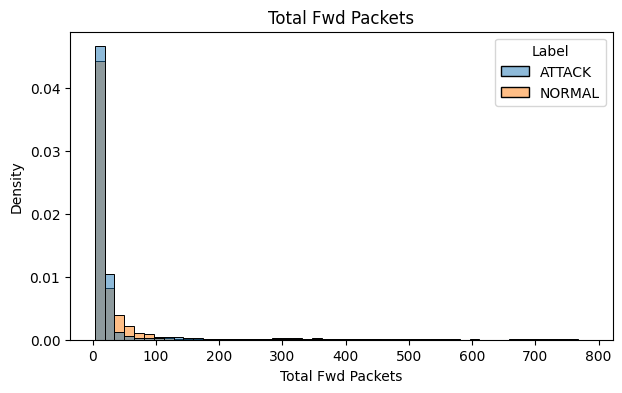

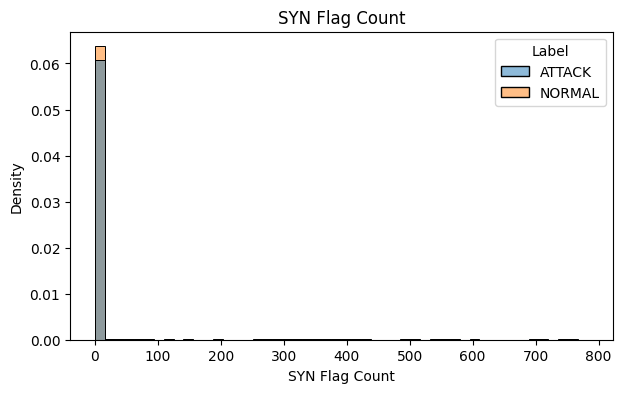

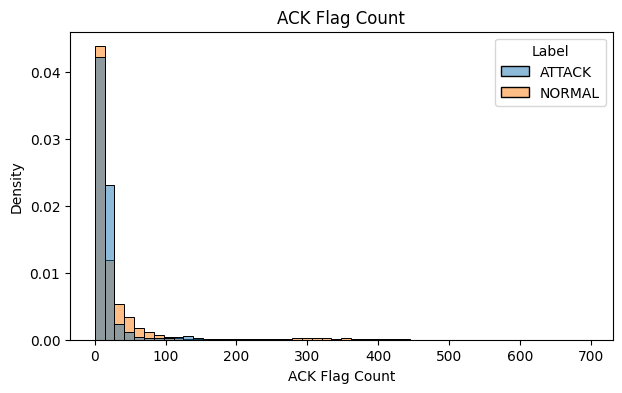

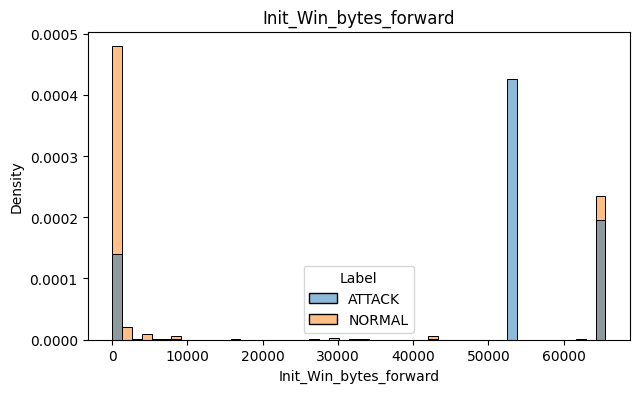

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

features = df.columns.drop("Label")

for col in features:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        hue="Label",
        bins=50,
        stat="density",
        common_norm=False,
        alpha=0.5
    )

    plt.title(col)

    plt.show()